In [145]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import seaborn as sns

In [47]:
# Load excel dataset
df=pd.read_excel('WOS.xlsx')

In [48]:
df.head()

,Last Material,Description,Mar'24,Apr'24,May'24,June'24,July'24,Aug'24,Sep'24,Oct'24,...,Demand 12m,Qty Expedite,Mrp Profile,D-Chain*,Git Sps,Git Km,Item Cat Group,Demand Spike %,New_Buy_LT,Repair_LT
0,452212806671,interface holder filters,0.60,1.14,1.14,1.06,0.57,0.49,0.09,0.06,...,5,0.85,ZMCA,ZS,0.0,0,ZSID,78.57%,35.0,0.0
1,452212896712,FILTER PLATE CU 0.5,1.48,1.45,1.45,1.12,0.93,1.11,1.24,0.84,...,10,0.00,ZMCA,ZS,0.0,0,ZSID,132.56%,45.0,45.0
2,452212896722,FILTER PLATE CU 1.5,3.42,3.37,3.27,2.75,2.63,2.63,1.20,1.56,...,33,0.00,ZMCA,ZS,0.0,0,ZSID,22.95%,105.0,0.0
3,452230035475,EDL TOOL,23.37,24.41,24.96,24.97,31.55,25.48,27.45,27.95,...,399,0.00,ZMTO,23,1.0,1,ZSID,-4.94%,140.0,0.0
4,453560816321,"Dodekaeder Phantom 12/15""",0.24,0.17,0.17,0.12,0.03,0.03,0.00,0.00,...,1,0.00,ZMCA,NaN,0.0,0,ZSID,No Demand,45.0,45.0


In [49]:
print(data.shape)
print(data.isnull().sum())

(41542, 60)
Last Material                0
Description                  0
Mar'24                       0
Apr'24                       0
May'24                       0
June'24                      0
July'24                      0
Aug'24                       0
Sep'24                       0
Oct'24                       0
Nov'24                       0
Dec'24                       0
Jan'25                       0
Feb'25                       0
Mar'25                       0
Apr'25                       0
May'25                       0
June'25                      0
Jul'25                       0
Aug'25                       0
Sep'25                       0
Oct'25                       0
Nov'25                       0
Dec'25                       0
Jan'26                       0
Feb'26                       0
Mar'26                       0
Apr'26                       0
May'26                       0
Open Po Qty Nb               0
Open Po Qty Rp               0
Total Open Po              

In [50]:
print(data.describe())

             Mar'24        Apr'24        May'24       June'24       July'24  \
count  41542.000000  41542.000000  41542.000000  41542.000000  41542.000000   
mean       2.249316      2.198217      2.193207      2.312254      2.355924   
std       27.195012     21.217995     21.294695     27.629949     32.019927   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      0.000000      0.000000      0.000000      0.000000   
50%        0.020000      0.010000      0.020000      0.000000      0.000000   
75%        0.590000      0.570000      0.580000      0.570000      0.450000   
max     4147.610000   2327.550000   2301.290000   3515.840000   3516.470000   

             Aug'24        Sep'24        Oct'24        Nov'24        Dec'24  \
count  41542.000000  41542.000000  41542.000000  41542.000000  41542.000000   
mean       2.245255      2.096094      2.112591      2.134559      2.094561   
std       31.842187     29.121370     34.574911    

In [51]:
# Clean Column Names
df.columns = df.columns.str.strip().str.replace(" ", "_")

df.columns

Index(['Last_Material', 'Description', 'Mar'24', 'Apr'24', 'May'24', 'June'24',
       'July'24', 'Aug'24', 'Sep'24', 'Oct'24', 'Nov'24', 'Dec'24', 'Jan'25',
       'Feb'25', 'Mar'25', 'Apr'25', 'May'25', 'June'25', 'Jul'25', 'Aug'25',
       'Sep'25', 'Oct'25', 'Nov'25', 'Dec'25', 'Jan'26', 'Feb'26', 'Mar'26',
       'Apr'26', 'May'26', 'Open_Po_Qty_Nb', 'Open_Po_Qty_Rp', 'Total_Open_Po',
       'Bu', 'Part_Nature', 'Supplier_New_Buy', 'Supplier_Name_New_Buy',
       'Supplier_D', 'Supplier_Name_D', 'Critical_Segment*', 'Mrpc',
       'Purch_Group', 'Sufficient_Po', 'Wos_Summary', 'Oh_U', 'Oh_Inventory',
       'Oh_D', 'Net_Inventory', 'Exact_WOS', 'Open_Bo_Qty', 'Bck_Sm_Qty',
       'Dmd_Last_30_Days', 'Demand_12m', 'Qty_Expedite', 'Mrp_Profile',
       'D-Chain*', 'Git_Sps', 'Git_Km', 'Item_Cat_Group', 'Demand_Spike_%',
       'New_Buy_LT', 'Repair_LT'],
      dtype='str')

In [52]:
# Check Missing Values
df.isnull().sum().sort_values(ascending=False)

Bck_Sm_Qty               41332
Supplier_Name_D          39794
Supplier_D               39650
D-Chain*                 19044
Supplier_Name_New_Buy    14284
                         ...  
Git_Km                       0
Item_Cat_Group               0
Demand_Spike_%               0
New_Buy_LT                   0
Repair_LT                    0
Length: 61, dtype: int64

In [53]:
# Remove duplicate
df.duplicated().sum()
df = df.drop_duplicates()

In [54]:
# Projected Inventory - Net Inventory

In [55]:
# Inventory Gap
df['Inventory_Gap'] = (
    df['Net_Inventory'] -
    df['Dmd_Last_30_Days']
)

In [56]:
# Classify Inventory Health
def inventory_status(x):
    if x < 0:
        return 'Shortage'
    elif x <= 2:
        return 'Critical'
    elif x <= 10:
        return 'Healthy'
    else:
        return 'Excess'

df['Inventory_Status'] = df['Inventory_Gap'].apply(inventory_status)

In [57]:
# Explore the Data
df.describe()
df['Inventory_Status'].value_counts()

Inventory_Status
Excess      17705
Healthy     13865
Critical     9746
Shortage      226
Name: count, dtype: int64

In [58]:
df.columns

Index(['Last_Material', 'Description', 'Mar'24', 'Apr'24', 'May'24', 'June'24',
       'July'24', 'Aug'24', 'Sep'24', 'Oct'24', 'Nov'24', 'Dec'24', 'Jan'25',
       'Feb'25', 'Mar'25', 'Apr'25', 'May'25', 'June'25', 'Jul'25', 'Aug'25',
       'Sep'25', 'Oct'25', 'Nov'25', 'Dec'25', 'Jan'26', 'Feb'26', 'Mar'26',
       'Apr'26', 'May'26', 'Open_Po_Qty_Nb', 'Open_Po_Qty_Rp', 'Total_Open_Po',
       'Bu', 'Part_Nature', 'Supplier_New_Buy', 'Supplier_Name_New_Buy',
       'Supplier_D', 'Supplier_Name_D', 'Critical_Segment*', 'Mrpc',
       'Purch_Group', 'Sufficient_Po', 'Wos_Summary', 'Oh_U', 'Oh_Inventory',
       'Oh_D', 'Net_Inventory', 'Exact_WOS', 'Open_Bo_Qty', 'Bck_Sm_Qty',
       'Dmd_Last_30_Days', 'Demand_12m', 'Qty_Expedite', 'Mrp_Profile',
       'D-Chain*', 'Git_Sps', 'Git_Km', 'Item_Cat_Group', 'Demand_Spike_%',
       'New_Buy_LT', 'Repair_LT', 'Inventory_Gap', 'Inventory_Status'],
      dtype='str')

In [59]:
df.head()

,Last_Material,Description,Mar'24,Apr'24,May'24,June'24,July'24,Aug'24,Sep'24,Oct'24,...,Mrp_Profile,D-Chain*,Git_Sps,Git_Km,Item_Cat_Group,Demand_Spike_%,New_Buy_LT,Repair_LT,Inventory_Gap,Inventory_Status
0,452212806671,interface holder filters,0.60,1.14,1.14,1.06,0.57,0.49,0.09,0.06,...,ZMCA,ZS,0.0,0,ZSID,78.57%,35.0,0.0,0.0,Critical
1,452212896712,FILTER PLATE CU 0.5,1.48,1.45,1.45,1.12,0.93,1.11,1.24,0.84,...,ZMCA,ZS,0.0,0,ZSID,132.56%,45.0,45.0,17.0,Excess
2,452212896722,FILTER PLATE CU 1.5,3.42,3.37,3.27,2.75,2.63,2.63,1.20,1.56,...,ZMCA,ZS,0.0,0,ZSID,22.95%,105.0,0.0,48.0,Excess
3,452230035475,EDL TOOL,23.37,24.41,24.96,24.97,31.55,25.48,27.45,27.95,...,ZMTO,23,1.0,1,ZSID,-4.94%,140.0,0.0,185.0,Excess
4,453560816321,"Dodekaeder Phantom 12/15""",0.24,0.17,0.17,0.12,0.03,0.03,0.00,0.00,...,ZMCA,NaN,0.0,0,ZSID,No Demand,45.0,45.0,15.0,Excess


In [60]:
monthly_cols = [
    "Mar'24","Apr'24","May'24","June'24","July'24","Aug'24",
    "Sep'24","Oct'24","Nov'24","Dec'24","Jan'25","Feb'25",
    "Mar'25","Apr'25","May'25","June'25","Jul'25","Aug'25",
    "Sep'25","Oct'25","Nov'25","Dec'25","Jan'26","Feb'26",
    "Mar'26","Apr'26","May'26"
]

len(monthly_cols)

27

In [61]:
# Validate Demand Data
df[monthly_cols].isnull().sum()
df[monthly_cols] = df[monthly_cols].fillna(0)

In [62]:
# Create Demand Statistics
df['Avg_Monthly_Demand'] = df[monthly_cols].mean(axis=1)

In [63]:
# Max Monthly Demand
df['Max_Monthly_Demand'] = df[monthly_cols].max(axis=1)

In [64]:
# Demand Variability (Std Dev)
df['Demand_StdDev'] = df[monthly_cols].std(axis=1)

In [65]:
# Coefficient of Variation
df['CV'] = (
    df['Demand_StdDev'] /
    df['Avg_Monthly_Demand']
)

In [66]:
# Demand Classification (XYZ Analysis)
def xyz_category(cv):
    if cv <= 0.5:
        return 'X'
    elif cv <= 1:
        return 'Y'
    else:
        return 'Z'

df['XYZ_Category'] = df['CV'].apply(xyz_category)

In [67]:
# ABC Analysis
df['Annual_Demand'] = df[monthly_cols].sum(axis=1)

In [68]:
# Sort by demand
df = df.sort_values(
    by='Annual_Demand',
    ascending=False
)

In [69]:
# Cumulative contribution
df['Cumulative_Demand_%'] = (
    df['Annual_Demand'].cumsum() /
    df['Annual_Demand'].sum()
) * 100

In [70]:
# ABC Classification
def abc_category(x):
    if x <= 80:
        return 'A'
    elif x <= 95:
        return 'B'
    else:
        return 'C'

df['ABC_Category'] = df['Cumulative_Demand_%'].apply(abc_category)

In [71]:
# Create ABC-XYZ Matrix
df['ABC_XYZ'] = (
    df['ABC_Category'] +
    df['XYZ_Category']
)

In [72]:
# Review Results
df[['Last_Material',
    'Avg_Monthly_Demand',
    'Demand_StdDev',
    'CV',
    'XYZ_Category',
    'Annual_Demand',
    'ABC_Category',
    'ABC_XYZ'
   ]].head()

,Last_Material,Avg_Monthly_Demand,Demand_StdDev,CV,XYZ_Category,Annual_Demand,ABC_Category,ABC_XYZ
2719,453567518181,3464.237407,520.205493,0.150165,X,93534.41,A,AX
17913,453561706671,2481.969259,198.010247,0.079779,X,67013.17,A,AX
1581,242201505034,1398.686667,1491.310534,1.066222,Z,37764.54,A,AZ
17912,453561706661,1157.859630,157.618015,0.136129,X,31262.21,A,AX
15920,453561512681,814.838889,77.960403,0.095676,X,22000.65,A,AX


In [73]:
# Analyze Segment Distribution
df['ABC_XYZ'].value_counts()

ABC_XYZ
CZ    28353
CY     5003
BX     3363
AX     1900
CX     1200
BY     1030
BZ      415
AY      178
AZ      100
Name: count, dtype: int64

In [74]:
# Create Effective Lead Time
import numpy as np

df['Effective_LT_Days'] = np.where(
    df['New_Buy_LT'].notnull(),
    df['New_Buy_LT'],
    np.where(
        df['Repair_LT'].notnull(),
        df['Repair_LT'],
        90
    )
)

In [75]:
# Validate Lead Time
df['Effective_LT_Days'].describe()
df['Effective_LT_Days'].isnull().sum()

np.int64(0)

In [77]:
df['LT_Months'] = (
    df['Effective_LT_Days'] / 30
)

In [78]:
# Lead Time Demand
df['Lead_Time_Demand'] = (
    df['Avg_Monthly_Demand'] *
    df['LT_Months']
)

In [79]:
# Safety Stock
z_score = 1.65

df['Safety_Stock'] = (
    z_score *
    df['Demand_StdDev'] *
    np.sqrt(df['LT_Months'])
)

e:\DS\Projects\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [80]:
# Reorder Point
df['ROP'] = (
    df['Lead_Time_Demand'] +
    df['Safety_Stock']
)

In [81]:
# Create Reorder Flag
df['Reorder_Flag'] = np.where(
    df['Net_Inventory'] < df['ROP'],
    'REORDER',
    'OK'
)

In [82]:
# Inventory Risk Level
def inventory_risk(row):

    if row['Net_Inventory'] <= 0:
        return 'Severe Risk'

    elif row['Net_Inventory'] < row['Safety_Stock']:
        return 'High Risk'

    elif row['Net_Inventory'] < row['ROP']:
        return 'Medium Risk'

    else:
        return 'Low Risk'


df['Inventory_Risk'] = df.apply(
    inventory_risk,
    axis=1
)

In [83]:
# Review Results
df[[
    'Last_Material',
    'ABC_XYZ',
    'Avg_Monthly_Demand',
    'Effective_LT_Days',
    'Lead_Time_Demand',
    'Safety_Stock',
    'ROP',
    'Net_Inventory',
    'Reorder_Flag',
    'Inventory_Risk'
]].head(10)

,Last_Material,ABC_XYZ,Avg_Monthly_Demand,Effective_LT_Days,Lead_Time_Demand,Safety_Stock,ROP,Net_Inventory,Reorder_Flag,Inventory_Risk
2719,453567518181,AX,3464.237407,45.0,5196.356111,1051.246365,6247.602477,11081.0,OK,Low Risk
17913,453561706671,AX,2481.969259,105.0,8686.892407,611.231365,9298.123773,17437.0,OK,Low Risk
1581,242201505034,AZ,1398.686667,45.0,2098.030000,3013.683631,5111.713631,23315.0,OK,Low Risk
17912,453561706661,AX,1157.859630,45.0,1736.789444,318.519063,2055.308507,8225.0,OK,Low Risk
15920,453561512681,AX,814.838889,30.0,814.838889,128.634664,943.473553,1981.0,OK,Low Risk
17284,453561480381,AZ,692.021852,89.0,2052.998160,2216.031591,4269.029751,7263.0,OK,Low Risk
16434,453561012551,AY,648.692222,45.0,973.038333,855.901320,1828.939653,14815.0,OK,Low Risk
7786,453566171031,AX,634.443333,14.0,296.073556,157.732628,453.806184,7328.0,OK,Low Risk
16527,453561131041,AX,527.118148,45.0,790.677222,423.651017,1214.328239,9782.0,OK,Low Risk
35268,453564748091,AX,465.196296,45.0,697.794444,228.242164,926.036608,229.0,REORDER,Medium Risk


In [85]:
# Analyze Risk Distribution
df['Inventory_Risk'].value_counts()

Inventory_Risk
Low Risk       35795
Severe Risk     5355
Medium Risk      313
High Risk         79
Name: count, dtype: int64

In [86]:
df['Reorder_Flag'].value_counts()

Reorder_Flag
OK         39951
REORDER     1591
Name: count, dtype: int64

In [88]:
# Excess Inventory Detection
df['Ideal_Inventory'] = (
    df['ROP'] +
    df['Safety_Stock']
)

In [89]:
# Excess Quantity
df['Excess_Qty'] = (
    df['Net_Inventory'] -
    df['Ideal_Inventory']
)

In [90]:
# Excess Flag
df['Excess_Flag'] = np.where(
    df['Excess_Qty'] > 0,
    'EXCESS',
    'NORMAL'
)

In [91]:
# Dead Stock Detection
df['Dead_Stock_Flag'] = np.where(
    (df['Annual_Demand'] == 0) &
    (df['Net_Inventory'] > 0),
    'DEAD_STOCK',
    'ACTIVE'
)

In [92]:
# Slow Moving Inventory
df['Slow_Moving_Flag'] = np.where(
    (df['Annual_Demand'] <= 2) &
    (df['Net_Inventory'] > 0),
    'SLOW_MOVING',
    'NORMAL'
)

In [93]:
# Procurement Priority
def procurement_priority(row):

    if row['Inventory_Risk'] == 'Severe Risk':
        return 'URGENT'

    elif row['ABC_Category'] == 'A' and row['Inventory_Risk'] != 'Low Risk':
        return 'HIGH'

    elif row['Reorder_Flag'] == 'REORDER':
        return 'MEDIUM'

    else:
        return 'LOW'


df['Procurement_Priority'] = df.apply(
    procurement_priority,
    axis=1
)

In [94]:
# Executive Inventory Action
def inventory_action(row):

    if row['Dead_Stock_Flag'] == 'DEAD_STOCK':
        return 'Liquidate / Phase-Out'

    elif row['Excess_Flag'] == 'EXCESS':
        return 'Reduce Inventory'

    elif row['Inventory_Risk'] == 'Severe Risk':
        return 'Immediate Procurement'

    elif row['Inventory_Risk'] == 'High Risk':
        return 'Expedite Supply'

    elif row['Reorder_Flag'] == 'REORDER':
        return 'Plan Replenishment'

    else:
        return 'Inventory Healthy'


df['Recommended_Action'] = df.apply(
    inventory_action,
    axis=1
)

In [95]:
# Review Final Intelligence Output
df[[
    'Last_Material',
    'ABC_XYZ',
    'Net_Inventory',
    'Annual_Demand',
    'ROP',
    'Safety_Stock',
    'Inventory_Risk',
    'Excess_Flag',
    'Dead_Stock_Flag',
    'Procurement_Priority',
    'Recommended_Action'
]].head(20)

,Last_Material,ABC_XYZ,Net_Inventory,Annual_Demand,ROP,Safety_Stock,Inventory_Risk,Excess_Flag,Dead_Stock_Flag,Procurement_Priority,Recommended_Action
2719,453567518181,AX,11081.0,93534.41,6247.602477,1051.246365,Low Risk,EXCESS,ACTIVE,LOW,Reduce Inventory
17913,453561706671,AX,17437.0,67013.17,9298.123773,611.231365,Low Risk,EXCESS,ACTIVE,LOW,Reduce Inventory
1581,242201505034,AZ,23315.0,37764.54,5111.713631,3013.683631,Low Risk,EXCESS,ACTIVE,LOW,Reduce Inventory
17912,453561706661,AX,8225.0,31262.21,2055.308507,318.519063,Low Risk,EXCESS,ACTIVE,LOW,Reduce Inventory
15920,453561512681,AX,1981.0,22000.65,943.473553,128.634664,Low Risk,EXCESS,ACTIVE,LOW,Reduce Inventory
17284,453561480381,AZ,7263.0,18684.59,4269.029751,2216.031591,Low Risk,EXCESS,ACTIVE,LOW,Reduce Inventory
16434,453561012551,AY,14815.0,17514.69,1828.939653,855.901320,Low Risk,EXCESS,ACTIVE,LOW,Reduce Inventory
7786,453566171031,AX,7328.0,17129.97,453.806184,157.732628,Low Risk,EXCESS,ACTIVE,LOW,Reduce Inventory
16527,453561131041,AX,9782.0,14232.19,1214.328239,423.651017,Low Risk,EXCESS,ACTIVE,LOW,Reduce Inventory
35268,453564748091,AX,229.0,12560.30,926.036608,228.242164,Medium Risk,NORMAL,ACTIVE,HIGH,Plan Replenishment


In [96]:
# Analyze Final Recommendation Distribution
df['Recommended_Action'].value_counts()

Recommended_Action
Reduce Inventory         23378
Liquidate / Phase-Out    12094
Immediate Procurement     5355
Inventory Healthy          323
Plan Replenishment         313
Expedite Supply             79
Name: count, dtype: int64

In [97]:
df['Procurement_Priority'].value_counts()

Procurement_Priority
LOW       35795
URGENT     5355
MEDIUM      250
HIGH        142
Name: count, dtype: int64

In [98]:
# Create Forecast Base Dataset
forecast_df = df[
    ['Last_Material'] + monthly_cols
].copy()

forecast_df.head()

,Last_Material,Mar'24,Apr'24,May'24,June'24,July'24,Aug'24,Sep'24,Oct'24,Nov'24,...,Aug'25,Sep'25,Oct'25,Nov'25,Dec'25,Jan'26,Feb'26,Mar'26,Apr'26,May'26
2719,453567518181,4147.61,2019.04,2081.58,3515.84,2901.65,2930.81,3410.96,3037.73,3255.69,...,3963.48,3644.82,3533.93,3844.86,3553.43,3319.10,3561.70,3561.70,3739.95,3581.56
17913,453561706671,2231.18,2327.55,2301.29,2348.43,3164.58,2808.57,2394.28,2299.14,2301.74,...,2537.96,2582.41,2553.99,2578.20,2572.60,2522.71,2586.36,2586.36,2554.81,2419.38
1581,242201505034,61.73,55.45,55.45,2185.94,1427.39,2703.62,2907.48,5200.49,4413.34,...,642.93,496.14,303.31,205.75,170.64,109.52,144.74,144.74,143.41,70.33
17912,453561706661,1127.65,1108.79,1116.13,1134.46,1244.54,1205.53,1094.72,1003.06,1017.82,...,1314.32,1327.51,1302.52,1351.59,1194.63,1156.60,1155.23,1155.23,1145.53,1132.97
15920,453561512681,965.32,981.70,966.72,811.60,854.88,822.13,884.81,872.03,860.58,...,811.98,699.51,739.84,727.95,735.19,748.00,743.01,743.01,770.85,761.90


In [99]:
# Moving Average Forecast
last_3_months = ["Mar'26", "Apr'26", "May'26"]

df['Forecast_3M_MA'] = (
    df[last_3_months].mean(axis=1)
)

In [100]:
# 6-Month Forecast
last_6_months = [
    "Dec'25",
    "Jan'26",
    "Feb'26",
    "Mar'26",
    "Apr'26",
    "May'26"
]

df['Forecast_6M_MA'] = (
    df[last_6_months].mean(axis=1)
)

In [101]:
# Forecast Trend Signal
df['Forecast_Trend_%'] = (
    (
        df['Forecast_3M_MA'] -
        df['Forecast_6M_MA']
    )
    /
    df['Forecast_6M_MA']
) * 100

In [102]:
# Demand Trend Classification
def demand_trend(x):

    if x > 20:
        return 'Rising'

    elif x < -20:
        return 'Declining'

    else:
        return 'Stable'


df['Demand_Trend'] = df[
    'Forecast_Trend_%'
].apply(demand_trend)

In [103]:
# Forecast-Based Risk
def future_risk(row):

    if (
        row['Demand_Trend'] == 'Rising'
        and row['Inventory_Risk'] != 'Low Risk'
    ):
        return 'Future Shortage Risk'

    elif (
        row['Demand_Trend'] == 'Declining'
        and row['Excess_Flag'] == 'EXCESS'
    ):
        return 'Future Excess Risk'

    else:
        return 'Stable'


df['Future_Risk'] = df.apply(
    future_risk,
    axis=1
)

In [104]:
# Review Forecast Intelligence
df[[
    'Last_Material',
    'ABC_XYZ',
    'Forecast_3M_MA',
    'Forecast_6M_MA',
    'Forecast_Trend_%',
    'Demand_Trend',
    'Inventory_Risk',
    'Future_Risk'
]].head(20)

,Last_Material,ABC_XYZ,Forecast_3M_MA,Forecast_6M_MA,Forecast_Trend_%,Demand_Trend,Inventory_Risk,Future_Risk
2719,453567518181,AX,3627.736667,3552.906667,2.106163,Stable,Low Risk,Stable
17913,453561706671,AX,2520.183333,2540.370000,-0.794635,Stable,Low Risk,Stable
1581,242201505034,AZ,119.493333,130.563333,-8.478644,Stable,Low Risk,Stable
17912,453561706661,AX,1144.576667,1156.698333,-1.047954,Stable,Low Risk,Stable
15920,453561512681,AX,758.586667,750.326667,1.100854,Stable,Low Risk,Stable
17284,453561480381,AZ,503.666667,485.461667,3.750039,Stable,Low Risk,Stable
16434,453561012551,AY,1238.620000,1123.148333,10.281070,Stable,Low Risk,Stable
7786,453566171031,AX,630.696667,631.968333,-0.201223,Stable,Low Risk,Stable
16527,453561131041,AX,900.530000,810.676667,11.083745,Stable,Low Risk,Stable
35268,453564748091,AX,364.166667,373.430000,-2.480608,Stable,Medium Risk,Stable


In [105]:
# Analyze Future Risk
df['Future_Risk'].value_counts()

Future_Risk
Stable                  35844
Future Excess Risk       5578
Future Shortage Risk      120
Name: count, dtype: int64

In [106]:
df['Demand_Trend'].value_counts()

Demand_Trend
Stable       32398
Declining     5942
Rising        3202
Name: count, dtype: int64

In [109]:
# Load VOB File
vob = pd.read_excel("VOB.xlsx")

vob.head()

,Send to vendor Y/N*,Priority,Vendor Number\n,Vendor Name,Internal/External,RMA Number\n,Purchase Document,PO Item,Material,Vendor Material Number,...,Critical Segment*,EUMDR Flag*,WOS*,Batch,BU*,DN,DN Sloc,DN Qty,Serial Number,Batch.1
0,Y,6,8004804,AAE B.V.,external,NaN,9600961917,10,459800064751,NaN,...,C4,NaN,0.00,U,IGT-S,NaN,NaN,NaN,NaN,U
1,Y,6,8004804,AAE B.V.,external,NaN,9600970156,10,459800064751,NaN,...,C4,NaN,0.00,U,IGT-S,NaN,NaN,NaN,NaN,U
2,Y,6,8004804,AAE B.V.,external,NaN,9600972703,10,459800064751,NaN,...,C4,NaN,0.00,U,IGT-S,NaN,NaN,NaN,NaN,U
3,Y,6,8004804,AAE B.V.,external,NaN,9600981962,10,459800301481,NaN,...,NC,NaN,0.00,U,IGT-S,NaN,NaN,NaN,NaN,U
4,Y,6,8004804,AAE B.V.,external,NaN,9600984044,10,459800072652,NaN,...,NC,NaN,6.87,U,IGT-S,NaN,NaN,NaN,NaN,U


In [110]:
# Check Columns
vob.columns

Index(['Send to vendor Y/N*', 'Priority', 'Vendor Number\n', 'Vendor Name',
       'Internal/External', 'RMA Number\n', 'Purchase Document', 'PO Item',
       'Material', 'Vendor Material Number', 'Description*', 'Open Quantity',
       'Delivery Date', 'Lead_time', 'PO Type**', 'Repair PO Age*',
       'Scrap Line*', 'Ticket ID*', 'Ticket Submitted Date*',
       'Ticket Status & Line Item Approval', 'Qty Confirmed Scrapped*',
       'Recycle Locally*', 'Expected Arrival Date',
       'Original Requested Del Date (Stat Del Date)', 'Supp Del Late*',
       'Overdue Status – Detailed*', 'Vendor Confirmation – Detailed*',
       'Due Soon**', 'Plant', 'MRPc', 'Purchasing Group', 'Buyer Name*',
       'Item Category**', 'Our Ref', 'Mfr Part Number', 'PO Created',
       'Created Past 10 Days**', 'Vendor confirm Date (AB)',
       'Delivery Confirm Date (LA)', 'Delivery Confirm Qty', 'Tracking No.',
       'Net_Price', 'Net Value Po Item', 'Cur', 'GR Date', 'Goods Rcpt Qty',
       'Previo

In [111]:
# Standardize Material Column
vob['Material'] = vob['Material'].astype(str)

df['Last_Material'] = df['Last_Material'].astype(str)

In [112]:
# Keep Required Columns Only
vob_price = vob[
    ['Material', 'Net_Price']
].copy()

In [113]:
# Merge Pricing Data
df = df.merge(
    vob_price,
    left_on='Last_Material',
    right_on='Material',
    how='left'
)

In [114]:
# Validate Pricing Merge
df['Net_Price'].isnull().sum()

np.int64(36950)

In [115]:
# Convert Net Price to Numeric
df['Net_Price'] = pd.to_numeric(
    df['Net_Price'],
    errors='coerce'
)

In [116]:
# Inventory Value
df['Inventory_Value'] = (
    df['Net_Inventory'] *
    df['Net_Price']
)

In [117]:
# Excess Inventory Value
df['Excess_Value'] = np.where(
    df['Excess_Qty'] > 0,
    df['Excess_Qty'] * df['Net_Price'],
    0
)

In [118]:
# Dead Stock Value
df['Dead_Stock_Value'] = np.where(
    df['Dead_Stock_Flag'] == 'DEAD_STOCK',
    df['Inventory_Value'],
    0
)

In [119]:
# Shortage Exposure Value
df['Shortage_Exposure_Value'] = np.where(
    df['Inventory_Risk'] == 'Severe Risk',
    abs(df['Net_Inventory']) * df['Net_Price'],
    0
)

In [121]:
# Executive KPIs
# Total Inventory Value
df['Inventory_Value'].sum()

np.float64(6080317691.100001)

In [122]:
# Total Excess Value
df['Excess_Value'].sum()

np.float64(3197707322.892731)

In [123]:
# Total Dead Stock Value
df['Dead_Stock_Value'].sum()

np.float64(94406468.81)

In [124]:
# Total Shortage Exposure
df['Shortage_Exposure_Value'].sum()

np.float64(0.0)

In [125]:
# Most Expensive Excess Inventory
df[[
    'Last_Material',
    'Description',
    'ABC_XYZ',
    'Inventory_Value',
    'Excess_Value',
    'Recommended_Action'
]].sort_values(
    by='Excess_Value',
    ascending=False
).head(20)

,Last_Material,Description,ABC_XYZ,Inventory_Value,Excess_Value,Recommended_Action
866,453561866752,EPIQ Acquisition Module,AX,11459176.35,11459176.35,Reduce Inventory
865,453561866752,EPIQ Acquisition Module,AX,11459176.35,11459176.35,Reduce Inventory
867,453561866752,EPIQ Acquisition Module,AX,11459176.35,11459176.35,Reduce Inventory
908,453561866752,EPIQ Acquisition Module,AX,11459176.35,11459176.35,Reduce Inventory
897,453561866752,EPIQ Acquisition Module,AX,11459176.35,11459176.35,Reduce Inventory
898,453561866752,EPIQ Acquisition Module,AX,11459176.35,11459176.35,Reduce Inventory
899,453561866752,EPIQ Acquisition Module,AX,11459176.35,11459176.35,Reduce Inventory
868,453561866752,EPIQ Acquisition Module,AX,11459176.35,11459176.35,Reduce Inventory
903,453561866752,EPIQ Acquisition Module,AX,11459176.35,11459176.35,Reduce Inventory
902,453561866752,EPIQ Acquisition Module,AX,11459176.35,11459176.35,Reduce Inventory


In [126]:
# Highest Financial Risk Shortages
df[[
    'Last_Material',
    'Description',
    'Inventory_Risk',
    'Shortage_Exposure_Value',
    'Procurement_Priority'
]].sort_values(
    by='Shortage_Exposure_Value',
    ascending=False
).head(20)

,Last_Material,Description,Inventory_Risk,Shortage_Exposure_Value,Procurement_Priority
0,453567518181,"CABLE TIE-50lbs TENSILE STRENGTH, 7.4"" L",Low Risk,0.0,LOW
1,453561706671,"Label,Plant Maintenance",Low Risk,0.0,LOW
2,242201505034,CABLE TIE,Low Risk,0.0,LOW
3,453561706661,"Label,Site ID",Low Risk,0.0,LOW
4,453561512681,"RP-PM Kit, Annual, V60/V60 Plus",Low Risk,0.0,LOW
5,453561512681,"RP-PM Kit, Annual, V60/V60 Plus",Low Risk,0.0,LOW
6,453561480381,"SWAB,LAUNDERED POLYURETHANE FOAM TIP,68M",Low Risk,0.0,LOW
7,453561012551,"CABLE TIE,11.5"",50LBS,NY",Low Risk,0.0,LOW
8,453566171031,"""Tie Wraps, Lg""",Low Risk,0.0,LOW
9,453561131041,"CABLE TIE,8""",Low Risk,0.0,LOW


In [127]:
# Create Clean Price Master
vob_price_clean = (
    vob.groupby('Material', as_index=False)
    ['Net_Price']
    .mean()
)

In [128]:
# Remove Old Pricing Columns
df = df.drop(
    columns=['Material', 'Net_Price'],
    errors='ignore'
)

In [129]:
# Re-Merge Correctly
df = df.merge(
    vob_price_clean,
    left_on='Last_Material',
    right_on='Material',
    how='left'
)

In [130]:
# Validate Duplication
df['Last_Material'].duplicated().sum()

np.int64(14728)

In [131]:
df.shape

(56270, 97)

In [132]:
# Recalculate Financial Metrics
df['Inventory_Value'] = (
    df['Net_Inventory'] *
    df['Net_Price']
)

In [133]:
df['Excess_Value'] = np.where(
    df['Excess_Qty'] > 0,
    df['Excess_Qty'] * df['Net_Price'],
    0
)

In [134]:
df['Dead_Stock_Value'] = np.where(
    df['Dead_Stock_Flag'] == 'DEAD_STOCK',
    df['Inventory_Value'],
    0
)

In [135]:
df['Shortage_Exposure_Value'] = np.where(
    df['Inventory_Risk'] == 'Severe Risk',
    abs(df['Net_Inventory']) * df['Net_Price'],
    0
)

In [136]:
# Recheck Top Excess Inventory
df[[
    'Last_Material',
    'Description',
    'ABC_XYZ',
    'Inventory_Value',
    'Excess_Value',
    'Recommended_Action'
]].sort_values(
    by='Excess_Value',
    ascending=False
).head(20)

,Last_Material,Description,ABC_XYZ,Inventory_Value,Excess_Value,Recommended_Action
12542,300015288891,FCO72200602-Allura R8.2.102 Multi TSMB,BZ,3.946790e+06,3.004900e+06,Reduce Inventory
12545,300015288891,FCO72200602-Allura R8.2.102 Multi TSMB,BZ,3.946790e+06,3.004900e+06,Reduce Inventory
12540,300015288891,FCO72200602-Allura R8.2.102 Multi TSMB,BZ,3.946790e+06,3.004900e+06,Reduce Inventory
12541,300015288891,FCO72200602-Allura R8.2.102 Multi TSMB,BZ,3.946790e+06,3.004900e+06,Reduce Inventory
12544,300015288891,FCO72200602-Allura R8.2.102 Multi TSMB,BZ,3.946790e+06,3.004900e+06,Reduce Inventory
12543,300015288891,FCO72200602-Allura R8.2.102 Multi TSMB,BZ,3.946790e+06,3.004900e+06,Reduce Inventory
950,453561866752,EPIQ Acquisition Module,AX,2.982566e+06,2.982566e+06,Reduce Inventory
953,453561866752,EPIQ Acquisition Module,AX,2.982566e+06,2.982566e+06,Reduce Inventory
954,453561866752,EPIQ Acquisition Module,AX,2.982566e+06,2.982566e+06,Reduce Inventory
934,453561866752,EPIQ Acquisition Module,AX,2.982566e+06,2.982566e+06,Reduce Inventory


In [137]:
# Check Duplicate Materials
df['Last_Material'].value_counts().head(20)

Last_Material
453561921802    504
453562089601    268
300004088644    211
452213303173    202
459801332271    164
459800151715    162
453564477401    122
459800300242    111
459800920772    106
453562060821    105
459800151726    105
453564477391    105
300007060511    104
453561866752     99
989603018948     98
453561981611     96
453562021713     91
453561673944     85
459801332291     85
453561974094     79
Name: count, dtype: int64

In [138]:
# Create Aggregated Master Dataset
master_df = df.groupby(
    'Last_Material',
    as_index=False
).agg({

    # Descriptive
    'Description': 'first',
    'ABC_XYZ': 'first',
    'ABC_Category': 'first',
    'XYZ_Category': 'first',

    # Demand
    'Annual_Demand': 'sum',
    'Avg_Monthly_Demand': 'mean',
    'Demand_StdDev': 'mean',

    # Inventory
    'Net_Inventory': 'sum',
    'ROP': 'sum',
    'Safety_Stock': 'sum',

    # Financial
    'Net_Price': 'mean',
    'Inventory_Value': 'sum',
    'Excess_Value': 'sum',
    'Dead_Stock_Value': 'sum',
    'Shortage_Exposure_Value': 'sum',

    # Flags
    'Inventory_Risk': 'first',
    'Recommended_Action': 'first',
    'Procurement_Priority': 'first'
})

In [139]:
# Validate Duplicates Removed
master_df['Last_Material'].duplicated().sum()

np.int64(0)

In [140]:
# Recheck Top Excess Materials
master_df[[
    'Last_Material',
    'Description',
    'ABC_XYZ',
    'Inventory_Value',
    'Excess_Value',
    'Recommended_Action'
]].sort_values(
    by='Excess_Value',
    ascending=False
).head(20)

,Last_Material,Description,ABC_XYZ,Inventory_Value,Excess_Value,Recommended_Action
20662,453561921802,EPIQ B-Cart Acquisition Module,AX,7.847022e+08,7.847022e+08,Reduce Inventory
20517,453561866752,EPIQ Acquisition Module,AX,2.952740e+08,2.952740e+08,Reduce Inventory
938,300004088644,ACE-e PCA with Fan assembly FRU,AX,2.334940e+08,1.345634e+08,Reduce Inventory
21163,453562060821,"ASSY, FRONT ACQUISITION w/CW, ITT, FRU",AY,9.208737e+07,9.208737e+07,Reduce Inventory
27857,453567560002,Spellman 80 KW RoHS CPM Assy,AX,1.163889e+08,8.828832e+07,Reduce Inventory
33649,459800608654,FRU kit RF-amp AN8137,AX,7.507241e+07,7.507241e+07,Reduce Inventory
20417,453561842279,"Transducer, X8-2t",AY,2.259009e+08,6.701419e+07,Reduce Inventory
20992,453562021713,"Svc, EBOX Assy, HW E.X, ZUUL, KABY LAKE,",AY,2.898275e+08,5.446671e+07,Reduce Inventory
40499,989603018948,DSTREAM INTERFACE-1.5T-IRF,AX,6.136873e+07,5.273332e+07,Reduce Inventory
36989,459801290173,dS Anterior 1.5T,AX,5.178987e+07,5.178987e+07,Reduce Inventory


In [141]:
# Executive Financial KPIs
# Total Inventory Value
master_df['Inventory_Value'].sum()

np.float64(6080317691.1)

In [142]:
# Total Excess Value
master_df['Excess_Value'].sum()

np.float64(3197707322.8927307)

In [143]:
# Total Dead Stock Value
master_df['Dead_Stock_Value'].sum()

np.float64(94406468.81)

In [144]:
# Total Shortage Exposure
master_df['Shortage_Exposure_Value'].sum()

np.float64(0.0)

In [146]:
# KPI Summary
total_inventory = master_df['Inventory_Value'].sum()

total_excess = master_df['Excess_Value'].sum()

dead_stock = master_df['Dead_Stock_Value'].sum()

print(f"Total Inventory Value: {total_inventory:,.0f}")

print(f"Total Excess Value: {total_excess:,.0f}")

print(f"Dead Stock Value: {dead_stock:,.0f}")

Total Inventory Value: 6,080,317,691
Total Excess Value: 3,197,707,323
Dead Stock Value: 94,406,469


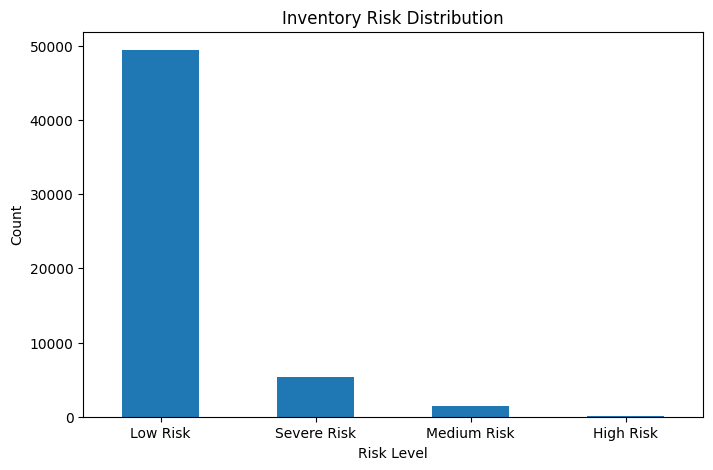

In [147]:
# Inventory Risk Distribution Chart
risk_counts = df['Inventory_Risk'].value_counts()

plt.figure(figsize=(8,5))

risk_counts.plot(kind='bar')

plt.title('Inventory Risk Distribution')

plt.xlabel('Risk Level')

plt.ylabel('Count')

plt.xticks(rotation=0)

plt.show()

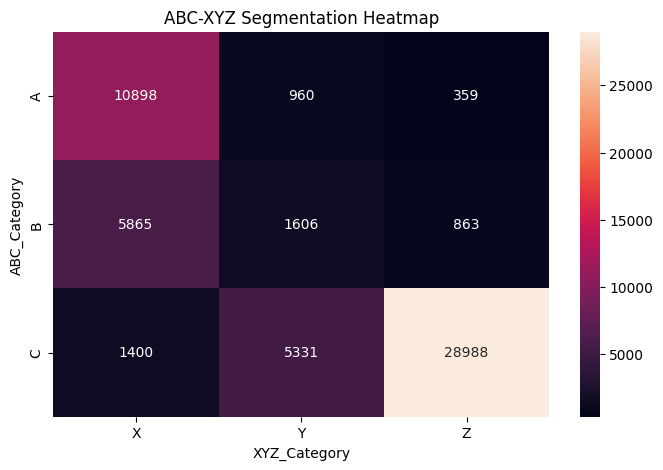

In [148]:
# ABC-XYZ Heatmap
abc_xyz_matrix = pd.crosstab(
    df['ABC_Category'],
    df['XYZ_Category']
)

plt.figure(figsize=(8,5))

sns.heatmap(
    abc_xyz_matrix,
    annot=True,
    fmt='d'
)

plt.title('ABC-XYZ Segmentation Heatmap')

plt.show()

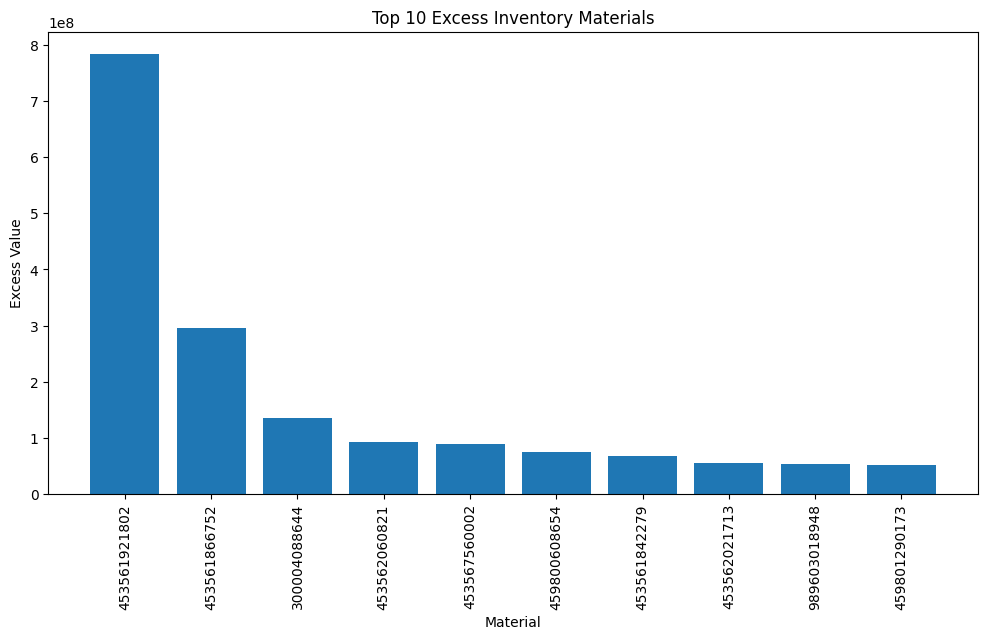

In [149]:
# Top Excess Inventory Chart
top_excess = master_df.sort_values(
    by='Excess_Value',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_excess['Last_Material'].astype(str),
    top_excess['Excess_Value']
)

plt.title('Top 10 Excess Inventory Materials')

plt.xlabel('Material')

plt.ylabel('Excess Value')

plt.xticks(rotation=90)

plt.show()

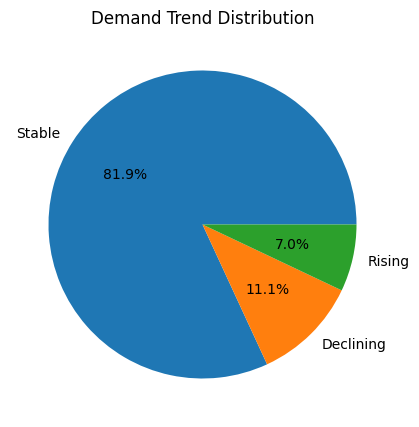

In [150]:
# Demand Trend Distribution
trend_counts = df['Demand_Trend'].value_counts()

plt.figure(figsize=(7,5))

trend_counts.plot(kind='pie', autopct='%1.1f%%')

plt.title('Demand Trend Distribution')

plt.ylabel('')

plt.show()

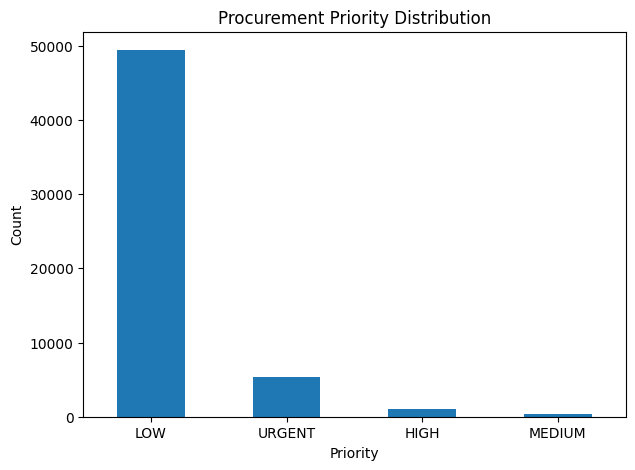

In [151]:
# Procurement Priority Chart
priority_counts = df[
    'Procurement_Priority'
].value_counts()

plt.figure(figsize=(7,5))

priority_counts.plot(kind='bar')

plt.title('Procurement Priority Distribution')

plt.xlabel('Priority')

plt.ylabel('Count')

plt.xticks(rotation=0)

plt.show()

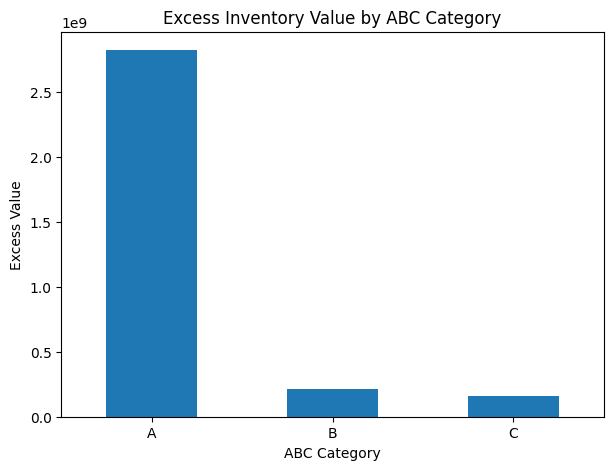

In [152]:
# Excess Value by ABC Category
abc_excess = master_df.groupby(
    'ABC_Category'
)['Excess_Value'].sum()

plt.figure(figsize=(7,5))

abc_excess.plot(kind='bar')

plt.title('Excess Inventory Value by ABC Category')

plt.xlabel('ABC Category')

plt.ylabel('Excess Value')

plt.xticks(rotation=0)

plt.show()

In [153]:
# Executive Summary Table
executive_summary = pd.DataFrame({

    'Metric': [

        'Total Inventory Value',
        'Total Excess Value',
        'Dead Stock Value',
        'Excess Percentage'

    ],

    'Value': [

        total_inventory,
        total_excess,
        dead_stock,
        (total_excess / total_inventory) * 100

    ]
})

executive_summary

,Metric,Value
0,Total Inventory Value,6.080318e+09
1,Total Excess Value,3.197707e+09
2,Dead Stock Value,9.440647e+07
3,Excess Percentage,5.259112e+01


In [154]:
master_df.to_csv(
    "master_inventory.csv",
    index=False
)